# Pipeline 1: Donor Retention / Lapse Risk

**Organization:** River of Life / Lighthouse Sanctuary (INTEX)  
**Methodology:** CRISP-DM–aligned end-to-end ML (see `pipeline_guide.md`)

This notebook predicts **monetary donor lapse**—whether a supporter who has given money historically will **not** make another **monetary** gift within the next **105 days** (midpoint of the 90–120 day stewardship window requested by stakeholders).

---

## 1. Problem Framing

### Business problem
Lighthouse Sanctuary relies on recurring generosity to fund safehouses, education, and wellbeing programs. When donors lapse silently, revenue becomes volatile and staff lack a prioritized list for **thank-you, check-in, and reactivation** outreach.

### Stakeholders
| Stakeholder | Interest |
|-------------|----------|
| **Development / admin** | Who to contact this week; campaign load; retention KPIs |
| **Front-line staff** | Simple risk flags in the admin dashboard (not raw model math) |
| **Donors** | Timely, respectful engagement—not spam |

### Why this matters
Proactive retention typically costs far less than re-acquiring lapsed donors. A ranked lapse-risk list turns a vague “we should steward donors” goal into **operational workflows**.

### Predictive vs explanatory (both required)
- **Predictive:** Produce a **binary `needs_outreach` flag** (True/False) per supporter using a calibrated classifier and an explicit threshold (**decision:** who enters the outreach queue this cycle).
- **Explanatory:** Quantify **which behaviors** (recency, frequency, monetary patterns, program spread) associate with lapse—**decision:** how to design campaigns and messaging (for example, emphasize recurring giving if it is protective in the data).

### Decision the model supports
**Prioritization:** Given limited staff time, staff should act on `needs_outreach = True` first, then sequence by donor value (frequency and tenure) for call/email intensity.

*Limitation:* Associations are **not causal**; interventions were not randomized. See Section 6.

---


## 2. Data Acquisition & Preparation

### Tables loaded
| Table | Role |
|-------|------|
| `supporters.csv` | Donor attributes (type, region, acquisition channel) |
| `donations.csv` | Gift history, amounts, recurrence, dates |
| `donation_allocations.csv` | How gifts map to programs and safehouses—**diversity** features |

### Join logic
1. **Donations → Supporters:** `donations.supporter_id` = `supporters.supporter_id` (many-to-one). Brings static demographics and supporter type onto each gift row when needed.
2. **Donations → Allocations:** `donations.donation_id` = `donation_allocations.donation_id` (one-to-many). Used to count distinct **program areas** funded before each snapshot date.

### Reproducibility
`DATA_DIR` and `OUTPUT_DIR` are resolved by walking upward from the current working directory until either `machine_learning/lighthouse_csv_v7` or `lighthouse_csv_v7` is found—so a TA can run top-to-bottom from **repo root**, **`machine_learning/`**, or **`ml_pipelines/`** without editing absolute paths. Random seeds are fixed. **Panel construction** (snapshot dates) is parameterized for batch scoring.

### Target definition (operational)
- **Cohort:** Supporters with **at least one monetary donation** strictly before snapshot date `as_of_date`.
- **Lapse (positive class):** **No** monetary donation with `as_of_date` < `donation_date` ≤ `as_of_date + 105 days`.

We use **105 days** as a single horizon between 90 and 120 days to keep one clear label; you can set `LAPSE_HORIZON_DAYS = 90` or `120` for sensitivity analysis.

### Leakage control
Features use only donations with `donation_date < as_of_date`. Labels use only the **future** window **after** `as_of_date`.

### Multiple rows per donor
Monthly snapshots create a **panel**. Rows for the same `supporter_id` are correlated. **Evaluation uses `GroupKFold` and group hold-out by `supporter_id`** so metrics are not optimistically biased.

---


In [1]:
# Configuration & imports
from __future__ import annotations

import json
import warnings
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    GroupShuffleSplit,
    cross_val_predict,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.85)

RANDOM_STATE = 42
LAPSE_HORIZON_DAYS = 105  # midpoint of 90–120 day window


def resolve_data_and_artifacts() -> tuple[Path, Path]:
    """All paths relative to the repo clone—works from repo root, machine_learning/, or ml_pipelines/."""
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        ml_data = p / "machine_learning" / "lighthouse_csv_v7"
        if ml_data.is_dir():
            out = p / "machine_learning" / "ml_pipelines" / "artifacts"
            return ml_data, out
        root_data = p / "lighthouse_csv_v7"
        if root_data.is_dir():
            out = p / "ml_pipelines" / "artifacts"
            return root_data, out
    raise FileNotFoundError(
        "Could not find lighthouse_csv_v7 (tried ./lighthouse_csv_v7 and "
        "./machine_learning/lighthouse_csv_v7). Run from the project repository."
    )


DATA_DIR, OUTPUT_DIR = resolve_data_and_artifacts()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPO_ROOT = OUTPUT_DIR.parent.parent  # machine_learning/ or project root containing ml_pipelines/

print("DATA_DIR:", DATA_DIR.resolve().relative_to(REPO_ROOT.resolve()))
print("OUTPUT_DIR:", OUTPUT_DIR.resolve().relative_to(REPO_ROOT.resolve()))
print("LAPSE_HORIZON_DAYS:", LAPSE_HORIZON_DAYS)


DATA_DIR: lighthouse_csv_v7
OUTPUT_DIR: ml_pipelines/artifacts
LAPSE_HORIZON_DAYS: 105


In [2]:
def load_raw_tables(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # Parse dates once at load for reproducible merges and filters.
    supporters = pd.read_csv(
        data_dir / "supporters.csv",
        parse_dates=["created_at", "first_donation_date"],
    )
    donations = pd.read_csv(
        data_dir / "donations.csv",
        parse_dates=["donation_date"],
    )
    allocations = pd.read_csv(
        data_dir / "donation_allocations.csv",
        parse_dates=["allocation_date"],
    )
    return supporters, donations, allocations


supporters_df, donations_df, allocations_df = load_raw_tables(DATA_DIR)
donations_with_alloc = donations_df.merge(
    allocations_df, on="donation_id", how="left", validate="one_to_many"
)
monetary = donations_df[donations_df["donation_type"] == "Monetary"].copy()

print("supporters:", supporters_df.shape)
print("donations:", donations_df.shape)
print("allocations:", allocations_df.shape)
print("monetary gifts:", monetary.shape)


supporters: (60, 15)
donations: (420, 13)
allocations: (521, 7)
monetary gifts: (234, 13)


In [3]:
def build_donor_panel(
    monetary_df: pd.DataFrame,
    donations_alloc_df: pd.DataFrame,
    supporters: pd.DataFrame,
    anchor_start: str = "2023-07-01",
    anchor_end: str = "2025-09-01",
    lapse_horizon_days: int = LAPSE_HORIZON_DAYS,
) -> pd.DataFrame:
    # One row per (supporter_id, as_of_date) with RFM-style features and lapse label.
    anchors = pd.date_range(anchor_start, anchor_end, freq="MS")
    rows: list[dict] = []
    max_d = monetary_df["donation_date"].max()

    for as_of in anchors:
        window_end = as_of + timedelta(days=lapse_horizon_days)
        if window_end > max_d:
            continue

        past = monetary_df[monetary_df["donation_date"] < as_of]
        supporter_ids = past["supporter_id"].unique()

        for sid in supporter_ids:
            pm = past[past["supporter_id"] == sid].sort_values("donation_date")
            last_dt = pm["donation_date"].max()
            recency_days = int((as_of - last_dt).days)
            frequency = int(len(pm))
            amounts = pm["amount"].fillna(0.0)
            monetary_sum = float(amounts.sum())
            monetary_mean = float(amounts.mean())
            has_recurring = bool(pm["is_recurring"].fillna(False).astype(bool).any())
            first_dt = pm["donation_date"].min()
            tenure_days = int((as_of - first_dt).days)
            if frequency >= 2:
                gaps = pm["donation_date"].diff().dt.days.dropna()
                mean_intergift_days = float(gaps.mean())
            else:
                mean_intergift_days = np.nan

            da = donations_alloc_df[
                (donations_alloc_df["supporter_id"] == sid)
                & (donations_alloc_df["donation_date"] < as_of)
            ]
            n_distinct_program_areas = int(da["program_area"].nunique(dropna=True))
            n_allocation_records = int(da["allocation_id"].notna().sum())

            future = monetary_df[
                (monetary_df["supporter_id"] == sid)
                & (monetary_df["donation_date"] > as_of)
                & (monetary_df["donation_date"] <= window_end)
            ]
            lapse_next_window = int(len(future) == 0)

            rows.append(
                {
                    "supporter_id": sid,
                    "as_of_date": as_of,
                    "lapse_next_window": lapse_next_window,
                    "recency_days": recency_days,
                    "frequency": frequency,
                    "monetary_sum": monetary_sum,
                    "monetary_mean": monetary_mean,
                    "has_recurring": int(has_recurring),
                    "tenure_days": tenure_days,
                    "mean_intergift_days": mean_intergift_days,
                    "n_distinct_program_areas": n_distinct_program_areas,
                    "n_allocation_records": n_allocation_records,
                }
            )

    panel = pd.DataFrame(rows)
    # Leave mean_intergift_days as NaN when frequency < 2; monetary features raw.
    # Median imputation and winsorization are fit inside the sklearn pipeline on training folds only.

    panel = panel.merge(
        supporters[
            [
                "supporter_id",
                "supporter_type",
                "relationship_type",
                "region",
                "acquisition_channel",
            ]
        ],
        on="supporter_id",
        how="left",
    )
    return panel


panel_df = build_donor_panel(monetary, donations_with_alloc, supporters_df)
print(panel_df.shape)
print(panel_df["lapse_next_window"].value_counts(normalize=True).rename("proportion"))
panel_df.head()


(1168, 16)
lapse_next_window
1    0.6875
0    0.3125
Name: proportion, dtype: float64


,supporter_id,as_of_date,lapse_next_window,recency_days,frequency,monetary_sum,monetary_mean,has_recurring,tenure_days,mean_intergift_days,n_distinct_program_areas,n_allocation_records,supporter_type,relationship_type,region,acquisition_channel
0,36,2023-07-01,1,76,3,3195.36,1065.1200,0,167,45.500000,4,5,SocialMediaAdvocate,PartnerOrganization,Mindanao,WordOfMouth
1,37,2023-07-01,1,29,1,502.90,502.9000,0,29,NaN,1,2,InKindDonor,PartnerOrganization,Visayas,Website
2,51,2023-07-01,0,51,1,1036.30,1036.3000,0,51,NaN,1,1,InKindDonor,Local,Luzon,WordOfMouth
3,20,2023-07-01,1,93,4,3702.31,925.5775,1,148,18.333333,3,7,Volunteer,International,Luzon,PartnerReferral
4,38,2023-07-01,1,41,1,1757.44,1757.4400,1,41,NaN,3,4,PartnerOrganization,PartnerOrganization,Mindanao,WordOfMouth


### Missing values
- **Monetary amount:** The modeling cohort uses **monetary** gifts; `amount` should be present. Any null is filled with **0 before row-level aggregation** so a rare bad row does not break the pipeline.
- **Mean inter-gift gap:** Undefined when only one gift exists before the snapshot; the raw panel keeps **NaN**. At modeling time, **`SimpleImputer(strategy="median")` inside the sklearn pipeline** learns the imputation value from **training data only** (per fold in CV), avoiding test-set leakage.

### Outliers
**Monetary sum and mean** are winsorized at the **1st and 99th percentiles learned on training data** via a custom transformer in the same pipeline—so held-out supporters never influence the caps.

---


## 3. Exploration (EDA)

We examine distributions and relationships that map to **stewardship theory**: recency, frequency, monetary value (RFM), recurring behavior, and **program-area breadth** from allocations.

**Insight goal:** If longer recency aligns with lapse, shorten **feedback loops** (timely impact stories). If recurring flags are protective, invest in **sustainer conversion**. If program breadth matters, messaging can reference **multiple impact lines** donors already fund.

---


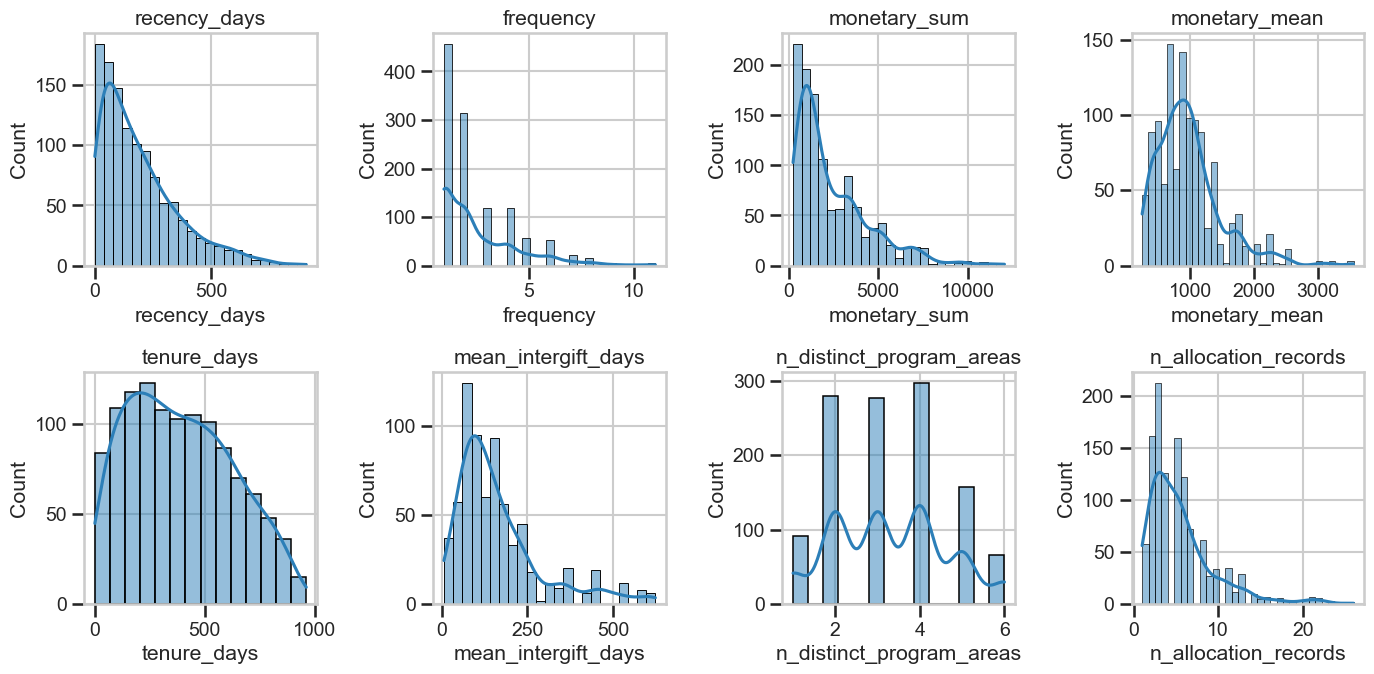

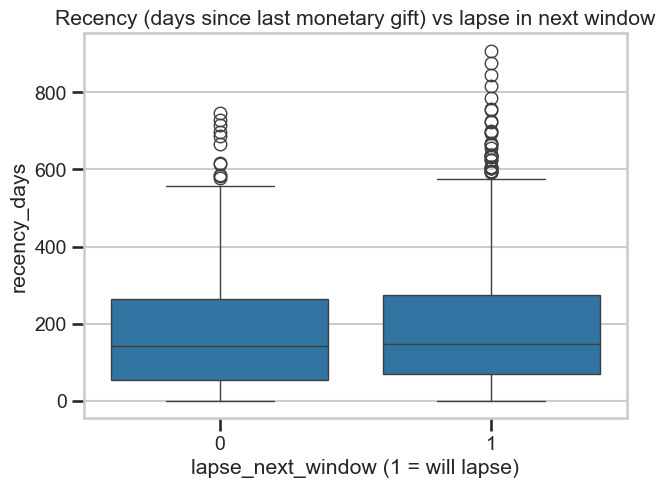

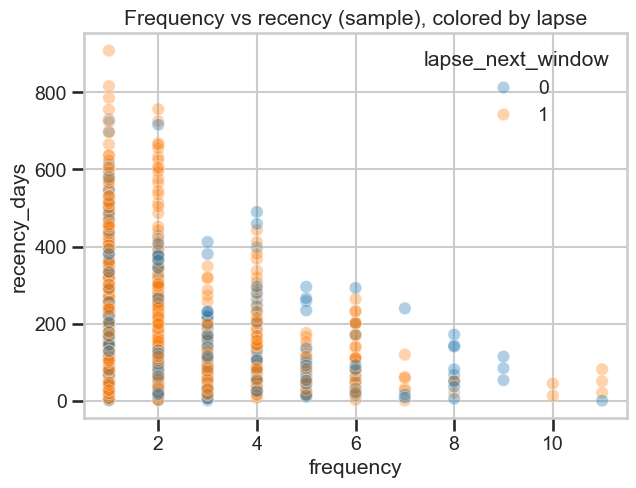

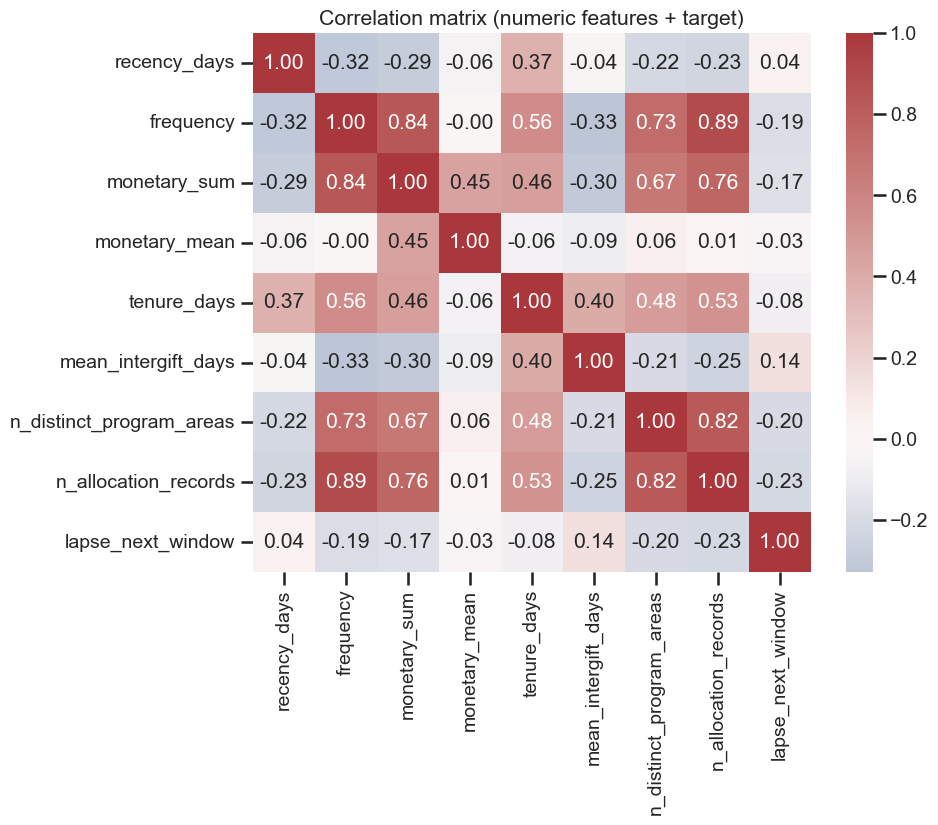

In [4]:
eda = panel_df.copy()
numeric_cols = [
    "recency_days",
    "frequency",
    "monetary_sum",
    "monetary_mean",
    "tenure_days",
    "mean_intergift_days",
    "n_distinct_program_areas",
    "n_allocation_records",
]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    s = eda[col].dropna() if col == "mean_intergift_days" else eda[col]
    sns.histplot(s, kde=True, ax=ax, color="#2c7fb8")
    ax.set_title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=eda, x="lapse_next_window", y="recency_days")
plt.title("Recency (days since last monetary gift) vs lapse in next window")
plt.xlabel("lapse_next_window (1 = will lapse)")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=eda.sample(min(800, len(eda)), random_state=RANDOM_STATE),
    x="frequency",
    y="recency_days",
    hue="lapse_next_window",
    alpha=0.35,
)
plt.title("Frequency vs recency (sample), colored by lapse")
plt.show()

corr = eda[numeric_cols + ["lapse_next_window"]].corr(numeric_only=True, min_periods=30)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix (numeric features + target)")
plt.show()


In [5]:
cat_summary = (
    eda.groupby("supporter_type")["lapse_next_window"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "lapse_rate"})
    .sort_values("lapse_rate", ascending=False)
)
cat_summary


,lapse_rate,count
supporter_type,,
Volunteer,0.788462,156
SocialMediaAdvocate,0.783898,236
InKindDonor,0.733533,334
PartnerOrganization,0.623529,85
SkillsContributor,0.603448,58
MonetaryDonor,0.541806,299


### EDA takeaways (business language + modeling decisions)
- **Recency** usually separates lapse vs active-in-window rows: longer gaps since the last monetary gift align with **no** gift in the next ~15 weeks (RFM). That supports keeping **recency** as a core feature and prioritizing **timely touchpoints** for long-idle donors in operations—not a causal claim.
- **Frequency and tenure** separate one-time testers from habitual givers. High **multicollinearity** among RFM-style fields is expected; we still include them for predictive power but interpret **logistic coefficients cautiously** (Section 6).
- **Mean inter-gift gap** is missing for single-gift histories; the **EDA histogram** uses non-missing values only. Modeling uses **median imputation fit on training folds** so we do not bake test information into the imputed value.
- **Monetary sum/mean** often show **heavy right tails** (a few large gifts). We cap tails **inside the fitted pipeline** on training quantiles only, then scale—so evaluation stays honest.
- **Allocations breadth** proxies engagement with programs; if it matters in models, stewardship messaging can reference **concrete funded areas**.

---


## 4. Modeling & Feature Selection

### Feature set (justification)
| Feature | Rationale |
|---------|-----------|
| `recency_days` | Core RFM: time since last monetary gift |
| `frequency` | Loyalty and habit |
| `monetary_sum`, `monetary_mean` | Historical monetary value |
| `has_recurring` | Sustainer behavior; often stabilizes cash flow |
| `tenure_days` | Relationship age with monetary giving |
| `mean_intergift_days` | Cadence; irregular donors may need different nudges |
| `n_distinct_program_areas`, `n_allocation_records` | Mission engagement breadth and granularity |
| `supporter_type`, `relationship_type`, `region`, `acquisition_channel` | Segments and acquisition context |

### Explanatory model
**Logistic regression (L2)** on scaled numeric features and one-hot categoricals: **interpretable coefficients** (direction on the log-odds scale).

### Predictive models
**Random forest** and **gradient boosted trees** capture nonlinearities; on small data they may **overfit**, so we compare honestly with **grouped cross-validation**.

### Feature selection
**L1 logistic regression** inside `SelectFromModel` provides a transparent gate; we report test metrics after selection vs the full logistic baseline.

### Preprocessing discipline
**Median imputation, winsorization of monetary columns, scaling, and one-hot encoding** live in a single `ColumnTransformer` + `Pipeline` so each **GroupKFold** training split fits transformers **only on that fold’s training rows**—no test leakage from global panel statistics.

### Hyperparameters
Each family is tuned with **`GridSearchCV` + `GroupKFold`** on the training supporter split, optimizing **ROC-AUC** (ranking quality for prioritization). Grids are intentionally small given sample size.

---


In [6]:
FEATURE_NUM = [
    "recency_days",
    "frequency",
    "monetary_sum",
    "monetary_mean",
    "has_recurring",
    "tenure_days",
    "mean_intergift_days",
    "n_distinct_program_areas",
    "n_allocation_records",
]
FEATURE_CAT = [
    "supporter_type",
    "relationship_type",
    "region",
    "acquisition_channel",
]

X = panel_df[FEATURE_NUM + FEATURE_CAT]
y = panel_df["lapse_next_window"]
groups = panel_df["supporter_id"]


class WinsorizeColumns(BaseEstimator, TransformerMixin):
    """Clip selected numeric columns to quantiles learned on the training fold only."""

    def __init__(self, column_indices: list[int], lower_q: float = 0.01, upper_q: float = 0.99):
        self.column_indices = column_indices
        self.lower_q = lower_q
        self.upper_q = upper_q

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_: dict[int, float] = {}
        self.hi_: dict[int, float] = {}
        for j in self.column_indices:
            col = X[:, j]
            lo, hi = np.nanquantile(col, [self.lower_q, self.upper_q])
            if hi < lo:
                lo, hi = hi, lo
            self.lo_[j] = float(lo)
            self.hi_[j] = float(hi)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        for j in self.column_indices:
            X[:, j] = np.clip(X[:, j], self.lo_[j], self.hi_[j])
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


_monetary_cols = [FEATURE_NUM.index("monetary_sum"), FEATURE_NUM.index("monetary_mean")]
_numeric_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("winsor", WinsorizeColumns(_monetary_cols)),
        ("scale", StandardScaler()),
    ]
)

preprocess = ColumnTransformer(
    [
        ("num", _numeric_pipe, FEATURE_NUM),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            FEATURE_CAT,
        ),
    ]
)


def make_full_pipeline(classifier) -> Pipeline:
    return Pipeline(
        steps=[
            ("prep", preprocess),
            ("clf", classifier),
        ]
    )


gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
group_train = groups.iloc[train_idx]

print("Train rows", len(X_train), "unique supporters", group_train.nunique())
print("Test rows", len(X_test), "unique supporters", groups.iloc[test_idx].nunique())


Train rows 850 unique supporters 41
Test rows 318 unique supporters 14


In [7]:
param_grids: dict[str, dict] = {
    "logistic_l2_balanced": {"clf__C": [0.01, 0.1, 1.0, 10.0]},
    "random_forest": {
        "clf__max_depth": [3, 5, None],
        "clf__min_samples_leaf": [2, 5, 10],
    },
    "gradient_boosting": {
        "clf__learning_rate": [0.03, 0.05, 0.1],
        "clf__max_depth": [2, 3],
    },
}

base_estimators = {
    "logistic_l2_balanced": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "gradient_boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200,
    ),
}

gkf = GroupKFold(n_splits=5)
tuning_rows: list[dict] = []
best_estimators_by_name: dict[str, Pipeline] = {}

for name, base in base_estimators.items():
    gs = GridSearchCV(
        make_full_pipeline(base),
        param_grids[name],
        cv=gkf,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
    )
    gs.fit(X_train, y_train, groups=group_train)
    best_estimators_by_name[name] = gs.best_estimator_
    tuning_rows.append(
        {
            "model": name,
            "roc_auc_cv_mean": gs.best_score_,
            "best_params": str(gs.best_params_),
        }
    )

cv_summary = (
    pd.DataFrame(tuning_rows).set_index("model").sort_values("roc_auc_cv_mean", ascending=False)
)
cv_summary


,roc_auc_cv_mean,best_params
model,,
logistic_l2_balanced,0.655520,{'clf__C': 0.1}
random_forest,0.599310,"{'clf__max_depth': 5, 'clf__min_samples_leaf': 2}"
gradient_boosting,0.580189,"{'clf__learning_rate': 0.05, 'clf__max_depth': 2}"


In [8]:
best_name = cv_summary.index[0]
best_pipe = best_estimators_by_name[best_name]

oof_proba = cross_val_predict(
    best_pipe,
    X_train,
    y_train,
    cv=gkf,
    groups=group_train,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

OUTREACH_CONTACT_FRAC = 0.25
threshold_capacity = float(np.quantile(oof_proba, 1.0 - OUTREACH_CONTACT_FRAC))

prec, rec, thr = precision_recall_curve(y_train, oof_proba)
denom = prec[:-1] + rec[:-1]
f1_scores = np.where(denom > 0, 2 * prec[:-1] * rec[:-1] / denom, 0.0)
best_f1_idx = int(np.argmax(f1_scores))
threshold_f1 = float(thr[best_f1_idx]) if len(thr) > 0 else 0.5

best_pipe.fit(X_train, y_train)
y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= threshold_capacity).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
print("Selected model (best grouped CV ROC-AUC):", best_name)
print(
    f"Operating threshold: top {OUTREACH_CONTACT_FRAC:.0%} of OOF train risk scores → "
    f"{threshold_capacity:.4f}"
)
print("Alternative threshold (max OOF F1):", f"{threshold_f1:.4f}")
pd.Series(metrics, name="test_set@capacity_threshold")


Selected model (best grouped CV ROC-AUC): logistic_l2_balanced
Operating threshold: top 25% of OOF train risk scores → 0.6699
Alternative threshold (max OOF F1): 0.2262


accuracy     0.534591
precision    0.694656
recall       0.457286
f1           0.551515
roc_auc      0.642667
Name: test_set@capacity_threshold, dtype: float64

                  precision    recall  f1-score   support

active_in_window       0.42      0.66      0.52       119
           lapse       0.69      0.46      0.55       199

        accuracy                           0.53       318
       macro avg       0.56      0.56      0.53       318
    weighted avg       0.59      0.53      0.54       318


Comparison @ default 0.5 probability cutoff:
                  precision    recall  f1-score   support

active_in_window       0.57      0.55      0.56       119
           lapse       0.74      0.75      0.75       199

        accuracy                           0.68       318
       macro avg       0.66      0.65      0.66       318
    weighted avg       0.68      0.68      0.68       318



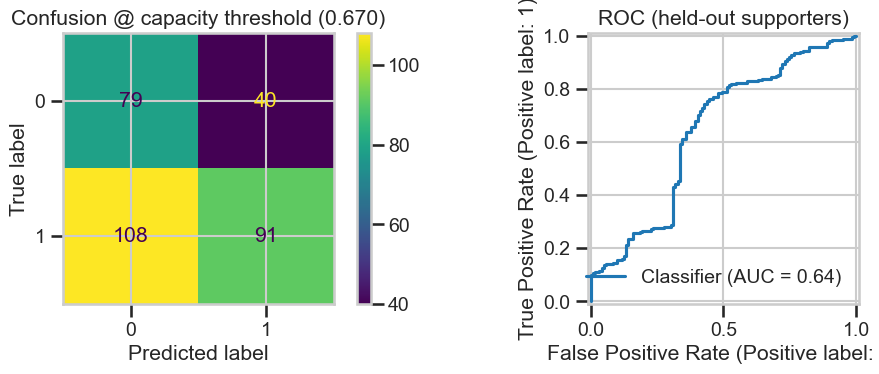

In [9]:
print(
    classification_report(
        y_test, y_pred, target_names=["active_in_window", "lapse"], zero_division=0
    )
)

y_pred_half = (y_proba >= 0.5).astype(int)
print("\nComparison @ default 0.5 probability cutoff:")
print(
    classification_report(
        y_test, y_pred_half, target_names=["active_in_window", "lapse"], zero_division=0
    )
)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[1])
ax[0].set_title(f"Confusion @ capacity threshold ({threshold_capacity:.3f})")
ax[1].set_title("ROC (held-out supporters)")
plt.tight_layout()
plt.show()


Explanatory diagnostic: numeric pairs with |r| >= 0.75 on training rows
               feature_a            feature_b        r
               frequency n_allocation_records 0.879026
n_distinct_program_areas n_allocation_records 0.830021
               frequency         monetary_sum 0.822998


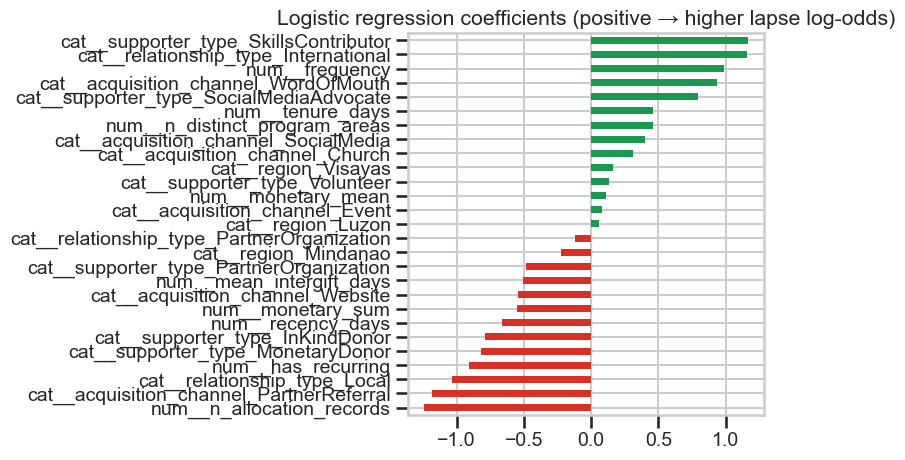

(cat__acquisition_channel_SocialMedia       0.399738
 num__n_distinct_program_areas              0.460632
 num__tenure_days                           0.461496
 cat__supporter_type_SocialMediaAdvocate    0.792076
 cat__acquisition_channel_WordOfMouth       0.935901
 num__frequency                             0.988676
 cat__relationship_type_International       1.159498
 cat__supporter_type_SkillsContributor      1.164912
 dtype: float64,
 num__n_allocation_records                  -1.238973
 cat__acquisition_channel_PartnerReferral   -1.182436
 cat__relationship_type_Local               -1.036155
 num__has_recurring                         -0.909994
 cat__supporter_type_MonetaryDonor          -0.816895
 cat__supporter_type_InKindDonor            -0.790886
 num__recency_days                          -0.662236
 num__monetary_sum                          -0.550895
 dtype: float64)

In [10]:
log_pipe = make_full_pipeline(
    LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
)
log_pipe.fit(X_train, y_train)

num_corr = X_train[FEATURE_NUM].corr(numeric_only=True, min_periods=20)
upper = np.triu(np.ones_like(num_corr, dtype=bool), k=1)
pairs = (
    num_corr.where(upper)
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "r"})
)
strong_pairs = pairs[pairs["r"].abs() >= 0.75].sort_values("r", key=np.abs, ascending=False)
print("Explanatory diagnostic: numeric pairs with |r| >= 0.75 on training rows")
print(strong_pairs.to_string(index=False) if len(strong_pairs) else "(none)")

prep = log_pipe.named_steps["prep"]
clf = log_pipe.named_steps["clf"]
feature_names = prep.get_feature_names_out()
coefs = pd.Series(clf.coef_.ravel(), index=feature_names).sort_values()

plt.figure(figsize=(8, max(4, len(coefs) * 0.18)))
coefs.plot(kind="barh", color=np.where(coefs.values < 0, "#d73027", "#1a9850"))
plt.title("Logistic regression coefficients (positive → higher lapse log-odds)")
plt.tight_layout()
plt.show()

coefs.tail(8), coefs.head(8)


In [11]:
selector_pipe = Pipeline(
    [
        ("prep", preprocess),
        (
            "select",
            SelectFromModel(
                LogisticRegression(
                    penalty="l1",
                    solver="saga",
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    C=0.3,
                ),
                threshold="median",
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

selector_pipe.fit(X_train, y_train)
sel_proba = selector_pipe.predict_proba(X_test)[:, 1]
sel_pred = (sel_proba >= 0.5).astype(int)
print("L1-selected logistic — test ROC-AUC:", roc_auc_score(y_test, sel_proba))
print(classification_report(y_test, sel_pred, zero_division=0))


L1-selected logistic — test ROC-AUC: 0.6331236011992737
              precision    recall  f1-score   support

           0       0.54      0.50      0.52       119
           1       0.71      0.74      0.73       199

    accuracy                           0.65       318
   macro avg       0.63      0.62      0.63       318
weighted avg       0.65      0.65      0.65       318



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 5. Evaluation & Interpretation (business terms)

### Metrics used
- **ROC-AUC:** How well scores rank lapses vs non-lapses across thresholds—useful when you will **tune the cutoff** based on staff capacity.
- **Recall:** Share of true lapses flagged—**prioritize higher recall** if missing a lapsing donor is costlier than an extra stewardship touch.
- **Precision:** Share of flagged donors who truly lapse—important when outreach volume is capped.
- **F1:** Harmonic compromise when you need a single headline number.

### Trade-offs
- **False negative:** Donor lapses but the model says low risk → **lost relationship and revenue**. Mitigation: lower the probability threshold or use **tiered** outreach (calls for top decile, email for the next).
- **False positive:** Donor would have given anyway but receives heavy touch → **possible donor fatigue**. Mitigation: gratitude-first scripts; avoid urgent guilt framing.

### Threshold choice (capacity-constrained outreach)
The notebook sets an operating cutoff using **out-of-fold** scores on the training panel: flag roughly the **top 25%** of donor-month rows by predicted risk (`OUTREACH_CONTACT_FRAC`), matching a team that can only deeply contact a minority of donors each cycle. **Default 0.5** is shown for comparison only—it is rarely optimal under class imbalance. Adjust `OUTREACH_CONTACT_FRAC` to your real weekly call/email capacity.

### Reading performance
Absolute metrics vary by supporter split; **grouped CV** is the main guardrail. In production, track **calibration** and **drift** quarterly.

---


## 6. Causal & Relationship Analysis (explanatory rigor)

### What this section can and cannot claim
We estimate a **conditional association** between historical RFM-style inputs and **future lapse** in a fixed window. That supports **hypothesis generation** and **segment narratives**, not **causal effects** of interventions.

### Identification gap (why this is not a causal design)
- **No randomized stewardship:** We observe who happened to be a recurring donor or a high-frequency donor; those states are **selected**, not assigned. Coefficients mix **true structural effects** (if any) with **confounding** (wealth, cause affinity, list acquisition quality, seasonal campaigns).
- **Omitted variables:** Unobserved factors (major life events, competing charities, email deliverability) can bias both magnitude and **sign** of coefficients if they correlate with included features.
- **Panel structure:** Multiple monthly rows per donor induce correlation in errors; we mitigate **evaluation** bias with grouped CV, but **standard errors on coefficients** in a naive logistic fit are not classical i.i.d.—interpret **width of evidence**, not p-values, unless you move to a cluster-robust specification (out of scope here).

### What we still do for “serious explanation”
- **Interpretable logistic** on the **same leakage-safe preprocessing** as prediction: directions are **marginal in a linear-logit sense**, conditional on other included covariates—**not** “if we change recency, lapse moves by X%” in a manipulative causal reading.
- **Multicollinearity check** (training numeric features): large pairwise correlations among RFM fields inflate variance of coefficients; we document strong pairs so readers do not over-interpret unstable signs.
- **Decision rule:** Use coefficients to **prioritize experiments** (e.g., A/B recurring prompts), then measure outcomes—not to justify policy from associations alone.

### Causality disclaimer (plain language)
A negative coefficient on `has_recurring` means **sustainers in this historical sample tended to lapse less** in the label window—not that **forcing** recurring enrollment **causes** retention without addressing confounders.

### Reading the coefficient chart
Positive values increase **log-odds of lapse**; negative values suggest **lower lapse risk** given the **linear model and included variables only**.

**Limitations:** Few unique supporters; panel dependence; external shocks (disasters, giving days) are not explicit features.

---


## 7. Deployment Plan

### How predictions are used in the app
1. A **batch scoring job** (scheduled nightly or weekly) in Python reads current `donations` and `supporters` (from a warehouse export or read replica).
2. The job builds features **as of `run_date`** and writes **one row per scored monetary donor** into PostgreSQL.
3. The website consumes **`needs_outreach` directly** to populate an **At-Risk Donors queue** (with optional risk-tier badges and sorting).

### Official decision rule
- The classifier outputs an internal score `lapse_probability`.
- The app-facing boolean is computed as `needs_outreach = lapse_probability >= operational_threshold`.
- In this notebook, the operational threshold is capacity-based (top 25% risk rows from OOF training predictions).

### Output schema (PostgreSQL)

```sql
CREATE TABLE IF NOT EXISTS donor_lapse_predictions (
    prediction_id BIGSERIAL PRIMARY KEY,
    supporter_id INTEGER NOT NULL REFERENCES supporters(supporter_id),
    as_of_date DATE NOT NULL,
    lapse_horizon_days INTEGER NOT NULL,
    lapse_probability DOUBLE PRECISION NOT NULL,
    needs_outreach BOOLEAN NOT NULL,
    risk_tier VARCHAR(16) NOT NULL,
    model_version VARCHAR(32) NOT NULL,
    top_positive_drivers JSONB,
    scored_at TIMESTAMPTZ NOT NULL DEFAULT NOW(),
    UNIQUE (supporter_id, as_of_date, lapse_horizon_days, model_version)
);

CREATE INDEX idx_donor_lapse_queue ON donor_lapse_predictions (needs_outreach, scored_at DESC);
CREATE INDEX idx_donor_lapse_supporter ON donor_lapse_predictions (supporter_id);
```

### Data flow
`Python batch job -> UPSERT PostgreSQL -> .NET (EF Core or Dapper) -> outreach queue/badges/filter`

### Sample upsert

```sql
INSERT INTO donor_lapse_predictions (
  supporter_id, as_of_date, lapse_horizon_days,
  lapse_probability, needs_outreach, risk_tier, model_version, top_positive_drivers
) VALUES (
  42, DATE '2026-04-06', 105, 0.71, TRUE, 'High', 'donor_lapse_v2',
  '["long_recency", "low_frequency"]'::jsonb
)
ON CONFLICT (supporter_id, as_of_date, lapse_horizon_days, model_version)
DO UPDATE SET
  lapse_probability = EXCLUDED.lapse_probability,
  needs_outreach = EXCLUDED.needs_outreach,
  risk_tier = EXCLUDED.risk_tier,
  top_positive_drivers = EXCLUDED.top_positive_drivers,
  scored_at = NOW();
```


In [12]:
from joblib import dump


def risk_tier(p: float) -> str:
    if p >= 0.66:
        return "High"
    if p >= 0.33:
        return "Medium"
    return "Low"


# Refit winning tuned pipeline (same steps as evaluation) on all labeled rows for deployment export.
final_pipe = clone(best_pipe)
final_pipe.fit(X, y)

# Official business decision threshold: same capacity-based cutoff used in evaluation.
operational_threshold = float(threshold_capacity)

latest_as_of = panel_df["as_of_date"].max()
score_rows = panel_df[panel_df["as_of_date"] == latest_as_of].copy()
X_score = score_rows[FEATURE_NUM + FEATURE_CAT]
score_rows = score_rows.assign(
    lapse_probability=final_pipe.predict_proba(X_score)[:, 1],
)
score_rows["needs_outreach"] = (score_rows["lapse_probability"] >= operational_threshold).astype(bool)
score_rows["risk_tier"] = score_rows["lapse_probability"].map(risk_tier)
score_rows["model_version"] = "donor_lapse_v2"
score_rows["lapse_horizon_days"] = LAPSE_HORIZON_DAYS

preview = score_rows[
    [
        "supporter_id",
        "as_of_date",
        "lapse_horizon_days",
        "lapse_probability",
        "needs_outreach",
        "risk_tier",
        "model_version",
        "recency_days",
        "frequency",
    ]
].sort_values(["needs_outreach", "lapse_probability"], ascending=[False, False])

dump(final_pipe, OUTPUT_DIR / "donor_lapse_model.joblib")
preview.head(15)


,supporter_id,as_of_date,lapse_horizon_days,lapse_probability,risk_category,model_version,recency_days,frequency
1146,18,2025-09-01,105,0.784451,High,donor_lapse_v2,327,2
1116,36,2025-09-01,105,0.776539,High,donor_lapse_v2,443,4
1133,39,2025-09-01,105,0.758867,High,donor_lapse_v2,78,3
1166,58,2025-09-01,105,0.726189,High,donor_lapse_v2,593,1
1128,43,2025-09-01,105,0.695964,High,donor_lapse_v2,232,3
1157,10,2025-09-01,105,0.667837,High,donor_lapse_v2,206,2
1135,32,2025-09-01,105,0.660058,High,donor_lapse_v2,45,3
1153,12,2025-09-01,105,0.659927,Medium,donor_lapse_v2,8,4
1125,16,2025-09-01,105,0.656433,Medium,donor_lapse_v2,48,2
1159,40,2025-09-01,105,0.656077,Medium,donor_lapse_v2,207,1


In [13]:
records = preview.head(5).to_dict(orient="records")
for r in records:
    r["as_of_date"] = str(r["as_of_date"].date())

with open(OUTPUT_DIR / "donor_lapse_sample_predictions.jsonl", "w") as f:
    for r in records:
        f.write(json.dumps(r, default=str) + chr(10))

print("Wrote:", OUTPUT_DIR / "donor_lapse_model.joblib")
print("Wrote:", OUTPUT_DIR / "donor_lapse_sample_predictions.jsonl")


Wrote: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/Intex2ElectricBoogaloo/machine_learning/ml_pipelines/artifacts/donor_lapse_model.joblib
Wrote: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/Intex2ElectricBoogaloo/machine_learning/ml_pipelines/artifacts/donor_lapse_sample_predictions.jsonl


## Operational Recommendation
- `needs_outreach = True` means the donor is predicted to be at elevated lapse risk within the 105-day horizon and should enter the active outreach queue.
- Staff should use this flag first for queue/filtering, then use `lapse_probability`, donor history, and relationship context to choose call vs email intensity.
- This is more actionable than raw scores alone because it creates a consistent yes/no decision rule that aligns with team capacity.
- False positives are acceptable when outreach is gratitude-first, but false negatives are costly (missed donors who lapse), so threshold review should happen quarterly.
- Next step: monitor conversion outcomes for flagged donors and recalibrate the threshold as staffing and campaign volume change.

---

**End of Pipeline 1 notebook.**
